<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseries_analysis_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        45,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,701 (178.52 KB)

 Trainable params: 45,701 (178.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0050 - mae: 0.0716
Epoch 2/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0024 - mae: 0.0506
Epoch 3/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0020 - mae: 0.0448
Epoch 4/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0018 - mae: 0.0432
Epoch 5/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0018 - mae: 0.0419
Epoch 6/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0017 - mae: 0.0412
Epoch 7/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0017 - mae: 0.0407
Epoch 8/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0017 - mae: 0.0402
Epoch 9/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0016 - mae: 0.0397
Epoch 10/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0016 - mae: 0.0389
Epoch 11/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0015 - mae: 0.0382
Epoch 12/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0015 - mae: 0.0376
Epoch 13/30
49

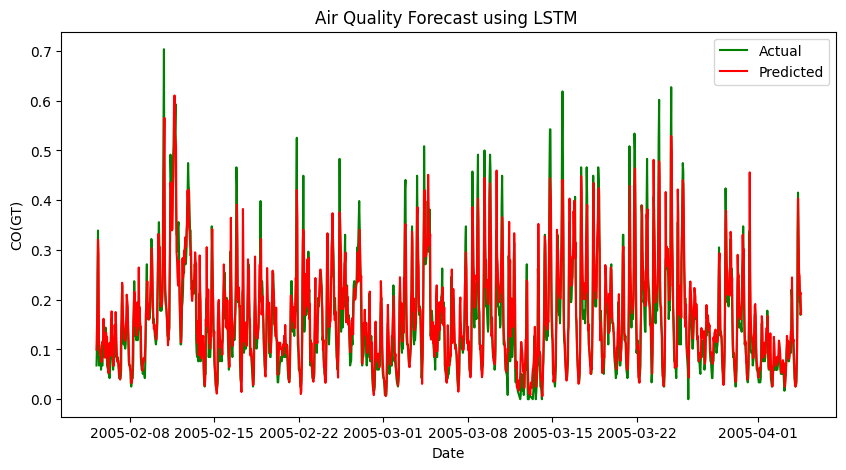

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np

# Load the dataset
air_quality_df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',')
# Data Preprocessing
air_quality_df["CO(GT)"] = air_quality_df["CO(GT)"].replace(-200, np.nan)
air_quality_df["CO(GT)"] = air_quality_df["CO(GT)"].interpolate(method="linear")
air_quality_df["CO(GT)"] = air_quality_df["CO(GT)"].bfill().ffill()
air_quality_df = air_quality_df.dropna(axis=1, how='all')
air_quality_df = air_quality_df.dropna(subset=['Date', 'Time'])
air_quality_df['Datetime'] = pd.to_datetime(air_quality_df['Date'] + ' ' + air_quality_df['Time'], format='%d/%m/%Y %H.%M.%S')
air_quality_df = air_quality_df.set_index('Datetime').drop(columns=['Date', 'Time'])
target_column = 'CO(GT)'

# List of common numeric columns to ensure they are correctly parsed
numeric_cols = ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
                'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
                'T', 'RH', 'AH']

for col in numeric_cols:
    if col in air_quality_df.columns:
        air_quality_df[col] = pd.to_numeric(air_quality_df[col], errors='coerce')

# Drop rows that have NaN in the target column after conversion
air_quality_df = air_quality_df.dropna(subset=[target_column])
# Ensure the index is sorted chronologically for seasonal_decompose
air_quality_df = air_quality_df.sort_index()
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(air_quality_df)
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window, 0])
    return np.array(X), np.array(y)


X, y = create_sequences(scaled_data, 20)
#Splitting data for testing and training
split = int(0.85 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
time = air_quality_df.index[-len(y_test):]
model = keras.Sequential()
model.add(keras.layers.LSTM(100, input_shape=(
    X_train.shape[1], X_train.shape[2])))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1))

model.compile(loss="huber", optimizer="adam", metrics=["mae"])
model.summary()
#Train the model
history = model.fit(X_train, y_train, epochs=30, batch_size=16)
#Prediction
pred = model.predict(X_test)
#Accuracy metrics
r2 = r2_score(y_test, pred)

# 2. Adjusted R-squared
# n = number of observations, k = number of independent variables (features)
n = len(y_test)
k = 1
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# 3. RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test,pred))

# 4. MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test,pred)
print(f"R-squared: {r2:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
#display result
plt.figure(figsize=(10, 5))
plt.plot(time, y_test, label="Actual", color="green")
plt.plot(time, pred,label="Predicted",color="red")
plt.title("Air Quality Forecast using LSTM ")
plt.xlabel("Date")
plt.ylabel("CO(GT)")
plt.legend()
plt.show()